In [12]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [13]:
import pandas as pd
df1 = pd.read_csv("../notebooks/dataprocessed/clear_output_cbe_reviews.csv")
df2 = pd.read_csv("../notebooks/dataprocessed/clear_output_BOA_reviews.csv")
df3 = pd.read_csv("../notebooks/dataprocessed/clear_output_DAHEN_reviews.csv")

In [14]:
print(df1['bank'].unique())
print(df2['bank'].unique())
print(df3['bank'].unique())

['CBE Bank']
['BOA Bank']
['Dashen Bank']


In [15]:
df_clean = pd.concat([df1, df2, df3], ignore_index=True)

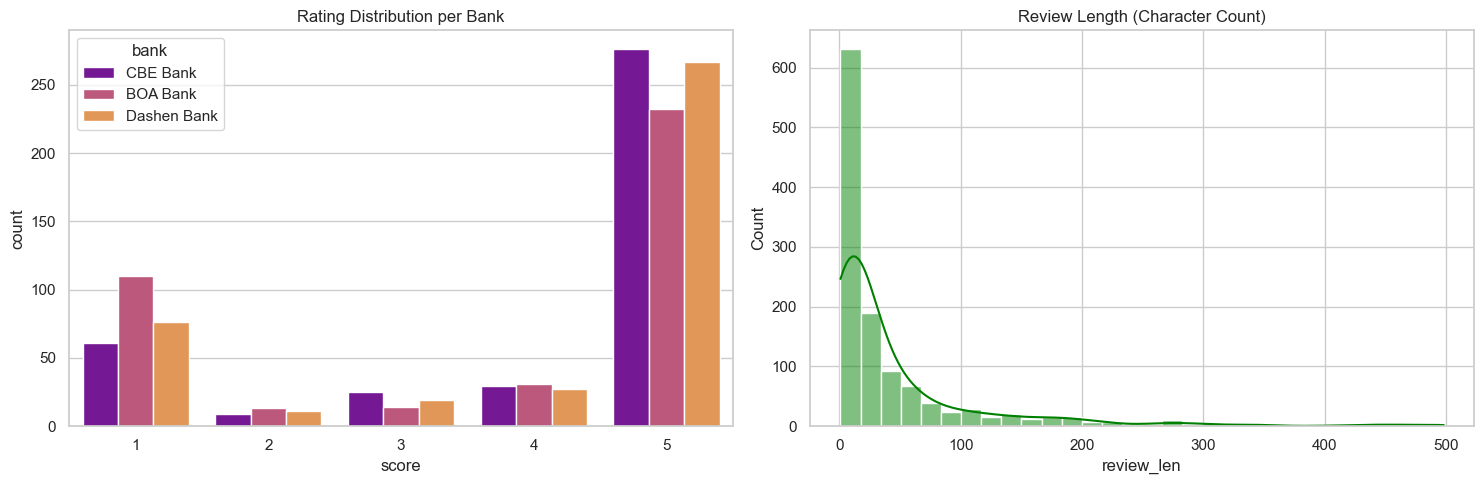

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Clean data
df_clean['bank'] = df_clean['bank'].astype(str).str.strip()
df_clean['content'] = df_clean['content'].astype(str)

# Figure
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1
sns.countplot(data=df_clean, x='score', hue='bank', palette='plasma', ax=ax[0])
ax[0].set_title('Rating Distribution per Bank')

# Plot 2
df_clean['review_len'] = df_clean['content'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='green')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout()
plt.show()

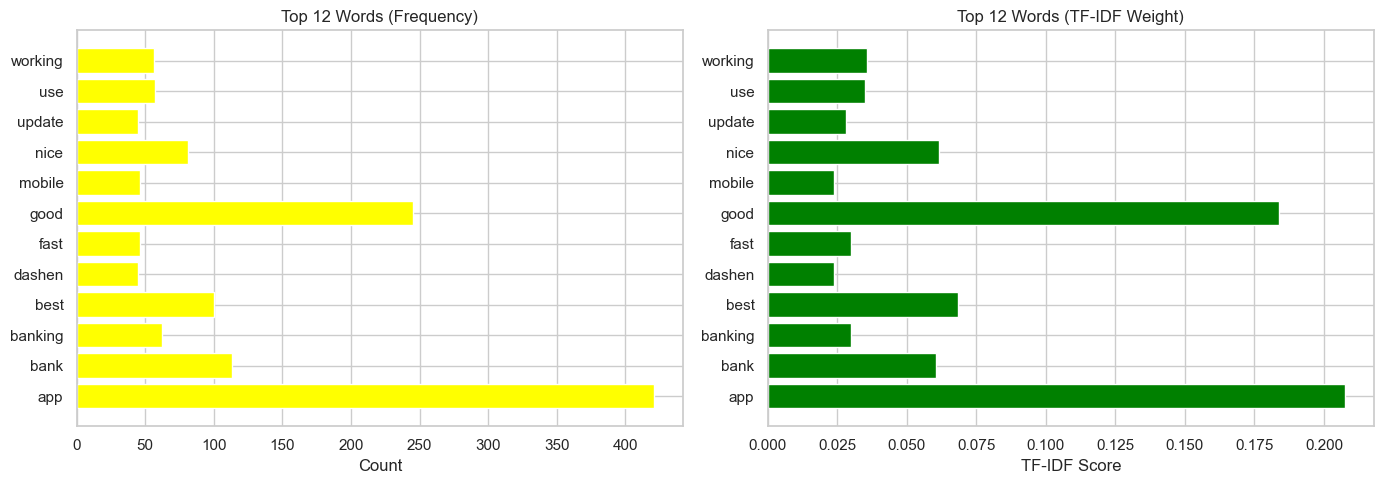

In [17]:
# Frequency (BoW) vs TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt

# Clean text (important to avoid errors)
texts = df_clean['content'].fillna("").astype(str)

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(texts)

# Count Vectorizer (BoW)
cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(texts)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Word Frequency (BoW)
axes[0].barh(
    cv_vec.get_feature_names_out(),
    X_cv.toarray().sum(axis=0),
    color='yellow'
)
axes[0].set_title('Top 12 Words (Frequency)')
axes[0].set_xlabel('Count')

# --- Right: TF-IDF importance
axes[1].barh(
    tfidf_vec.get_feature_names_out(),
    X_tfidf.toarray().mean(axis=0),
    color='Green'
)
axes[1].set_title('Top 12 Words (TF-IDF Weight)')
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()

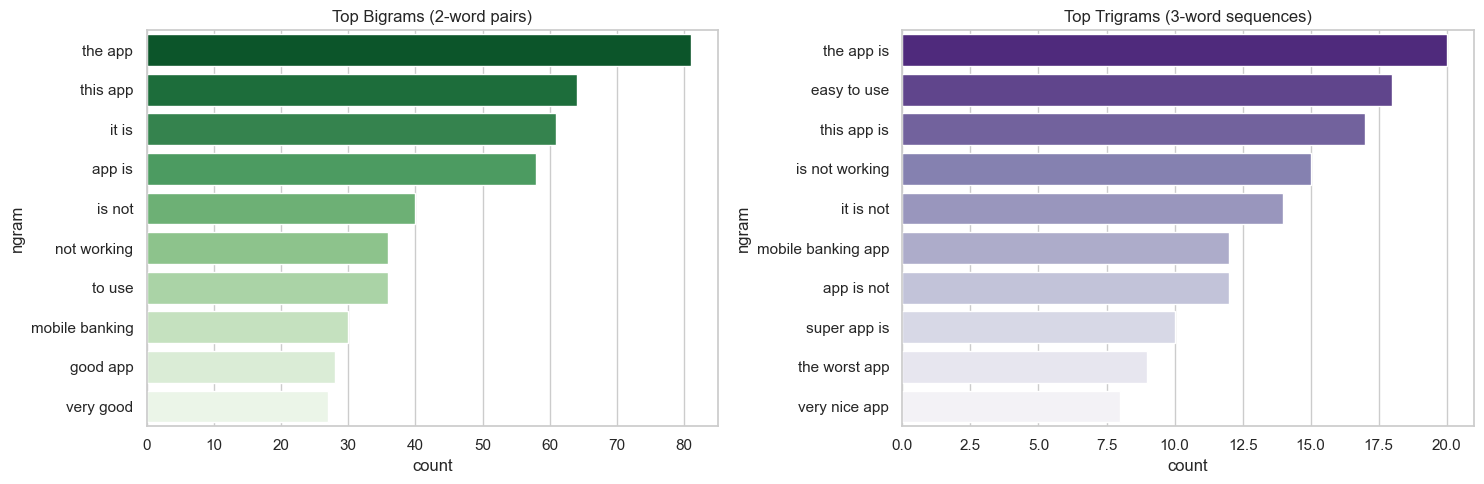

In [18]:

## Section 7 — N-gram Analysis (Context Discovery)
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['content'], 2)
tri = get_top_ngrams(df_clean['content'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

In [19]:
import nltk

print("Downloading all required NLTK data...")

nltk.download('punkt', quiet=False)
nltk.download('punkt_tab', quiet=False)        # Most important for your error
nltk.download('averaged_perceptron_tagger', quiet=False)
nltk.download('stopwords', quiet=False)

print("\n✅ Download finished!")


✅ Download finished!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Extracting keywords...

          TOP 15 KEYWORDS ACROSS ALL BANKS
    Keyword  Count
1      good    245
2       not    141
3      bank    113
4      best    100
5       for     87
6      nice     81
7   banking     62
8       use     57
9      with     57
10  working     56
11     when     48
12   mobile     46
13     fast     46
14   update     45
15   dashen     45


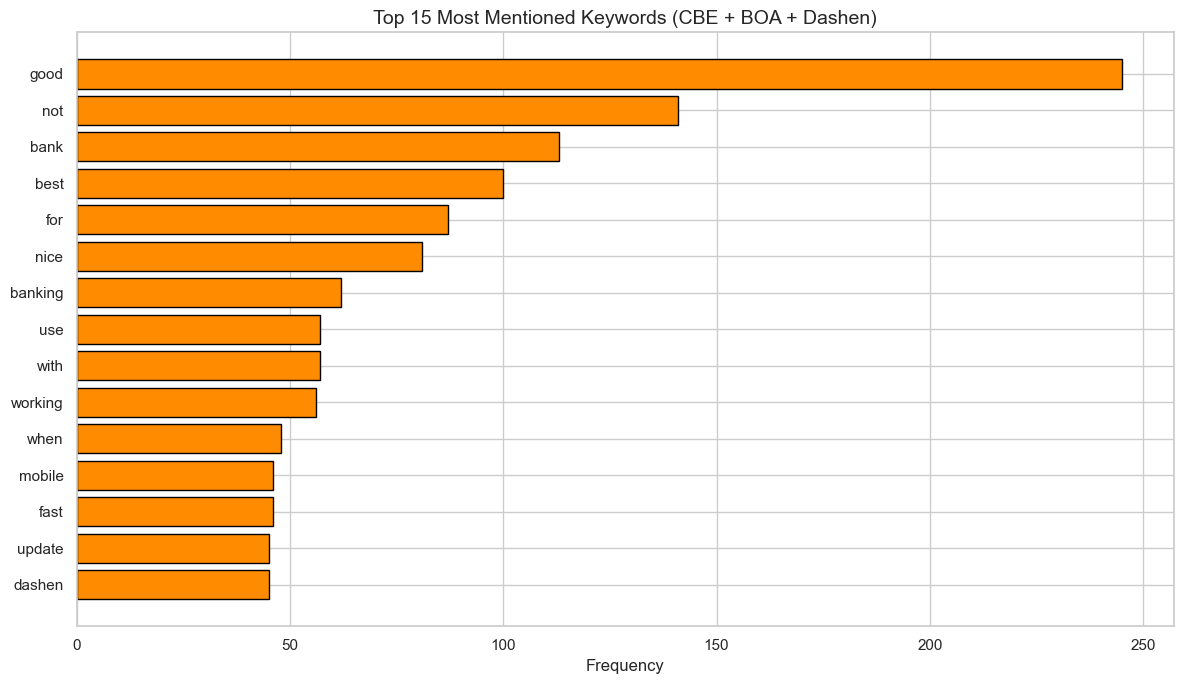


          TOP 10 KEYWORDS PER BANK

🔹 CBE Bank (400 reviews)
   good                 :   99
   not                  :   51
   best                 :   32
   nice                 :   32
   for                  :   31
   cbe                  :   20
   update               :   19
   bank                 :   19
   working              :   18
   use                  :   15

🔹 BOA Bank (400 reviews)
   good                 :   80
   not                  :   45
   best                 :   36
   bank                 :   33
   when                 :   25
   banking              :   25
   mobile               :   23
   nice                 :   22
   boa                  :   22
   can                  :   21

🔹 Dashen Bank (400 reviews)
   good                 :   66
   bank                 :   61
   dashen               :   45
   not                  :   45
   for                  :   42
   best                 :   32
   super                :   32
   banking              :   30
   nice        

In [20]:
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

# Stop words (English + common Amharic)
english_stop = {'the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were',
                'i', 'you', 'he', 'she', 'it', 'we', 'they', 'this', 'that', 'very',
                'app', 'application'}  # added common words

amharic_stop = {'ብዙ', 'ጥፋት', 'እና', 'ይህ', 'እኔ', 'አንተ', 'ነው', 'አፕ', 'በጣም'}

stop_words = english_stop.union(amharic_stop)

# ====================== KEYWORD EXTRACTION FUNCTION ======================
def extract_keywords(text):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return []
    
    # Extract words (supports English + Amharic)
    words = re.findall(r'\b\w+\b', text.lower())
    
    keywords = [w for w in words 
                if len(w) > 2 and w not in stop_words]
    return keywords


# ====================== RUN ANALYSIS ======================
print("Extracting keywords...")

df_clean['keywords'] = df_clean['content'].apply(extract_keywords)

# ====================== OVERALL TOP KEYWORDS ======================
all_keywords = [k for ks in df_clean['keywords'] for k in ks]
keyword_counts = Counter(all_keywords).most_common(15)

print("\n" + "="*90)
print("          TOP 15 KEYWORDS ACROSS ALL BANKS")
print("="*90)

keyword_df = pd.DataFrame(keyword_counts, columns=['Keyword', 'Count'])
keyword_df.index = range(1, len(keyword_df) + 1)
print(keyword_df.to_string())

# Plot - Overall
plt.figure(figsize=(12, 7))
words = [x[0] for x in keyword_counts][::-1]
counts = [x[1] for x in keyword_counts][::-1]

plt.barh(words, counts, color='darkorange', edgecolor='black')
plt.title('Top 15 Most Mentioned Keywords (CBE + BOA + Dashen)', fontsize=14)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# ====================== TOP KEYWORDS PER BANK ======================
print("\n" + "="*90)
print("          TOP 10 KEYWORDS PER BANK")
print("="*90)

banks = ['CBE Bank', 'BOA Bank', 'Dashen Bank']

for bank in banks:
    bank_df = df_clean[df_clean['bank'] == bank]
    if len(bank_df) == 0:
        print(f"\n{bank}: No data available")
        continue
        
    bank_keywords = [k for ks in bank_df['keywords'] for k in ks]
    bank_counts = Counter(bank_keywords).most_common(10)
    
    print(f"\n🔹 {bank} ({len(bank_df)} reviews)")
    if bank_counts:
        for keyword, count in bank_counts:
            print(f"   {keyword:20} : {count:4}")
    else:
        print("   No keywords extracted")

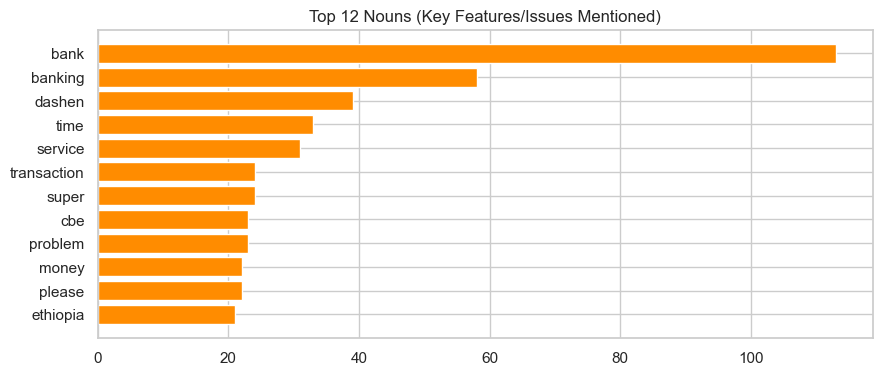

In [21]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

df1 = pd.read_csv("dataprocessed/clear_output_cbe_reviews.csv", usecols=['bank', 'content'])
df2 = pd.read_csv("dataprocessed/clear_output_BOA_reviews.csv", usecols=['bank', 'content'])
df3 = pd.read_csv("dataprocessed/clear_output_DAHEN_reviews.csv", usecols=['bank', 'content'])

df_clean = pd.concat([df1, df2, df3], ignore_index=True)
# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['content'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

Extracting keywords...


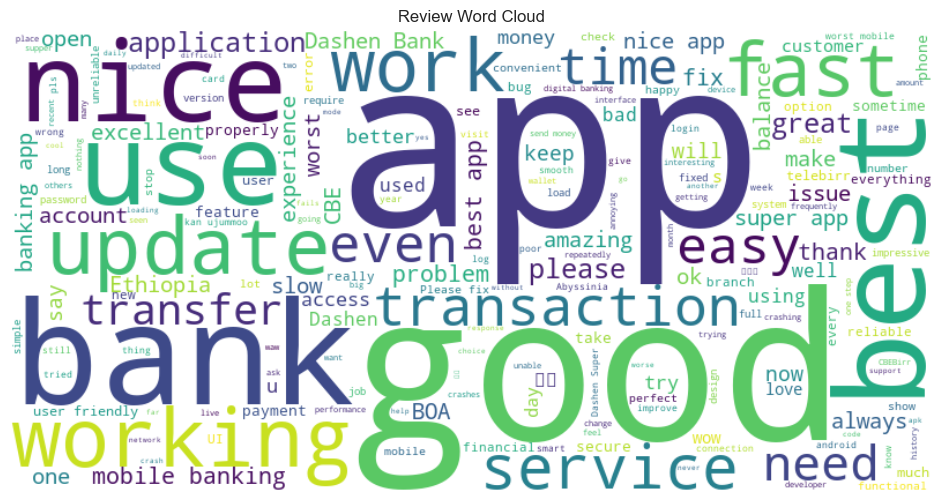

In [22]:
# Cell 8: Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text_combined = " ".join(df_clean['content'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)


print("Extracting keywords...")

df_clean['keywords'] = df_clean['content'].apply(extract_keywords)

# ====================== OVERALL TOP KEYWORDS ======================
all_keywords = [k for ks in df_clean['keywords'] for k in ks]
keyword_counts = Counter(all_keywords).most_common(15)




plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

In [23]:
import re
from collections import Counter

# Get all words from your reviews
all_words = []
for text in df_clean['content']:
    if isinstance(text, str):
        words = re.findall(r'\b\w+\b', text.lower())
        all_words.extend(words)

word_freq = Counter(all_words).most_common(50)

print("🔍 TOP 50 MOST COMMON WORDS IN YOUR REVIEWS:")
print("="*70)
for word, count in word_freq:
    print(f"{word:20} : {count}")

🔍 TOP 50 MOST COMMON WORDS IN YOUR REVIEWS:
app                  : 421
it                   : 360
the                  : 352
and                  : 254
to                   : 253
good                 : 245
is                   : 244
i                    : 235
this                 : 145
not                  : 141
a                    : 116
bank                 : 113
very                 : 112
best                 : 100
t                    : 96
s                    : 92
for                  : 87
nice                 : 81
of                   : 76
my                   : 73
in                   : 70
but                  : 65
banking              : 62
you                  : 60
use                  : 57
with                 : 57
working              : 56
so                   : 51
when                 : 48
mobile               : 46
fast                 : 46
update               : 45
dashen               : 45
can                  : 42
on                   : 41
please               : 40
work  

In [24]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['content'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['content'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['content'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.62
neutral     0.25
negative    0.13
Name: proportion, dtype: float64


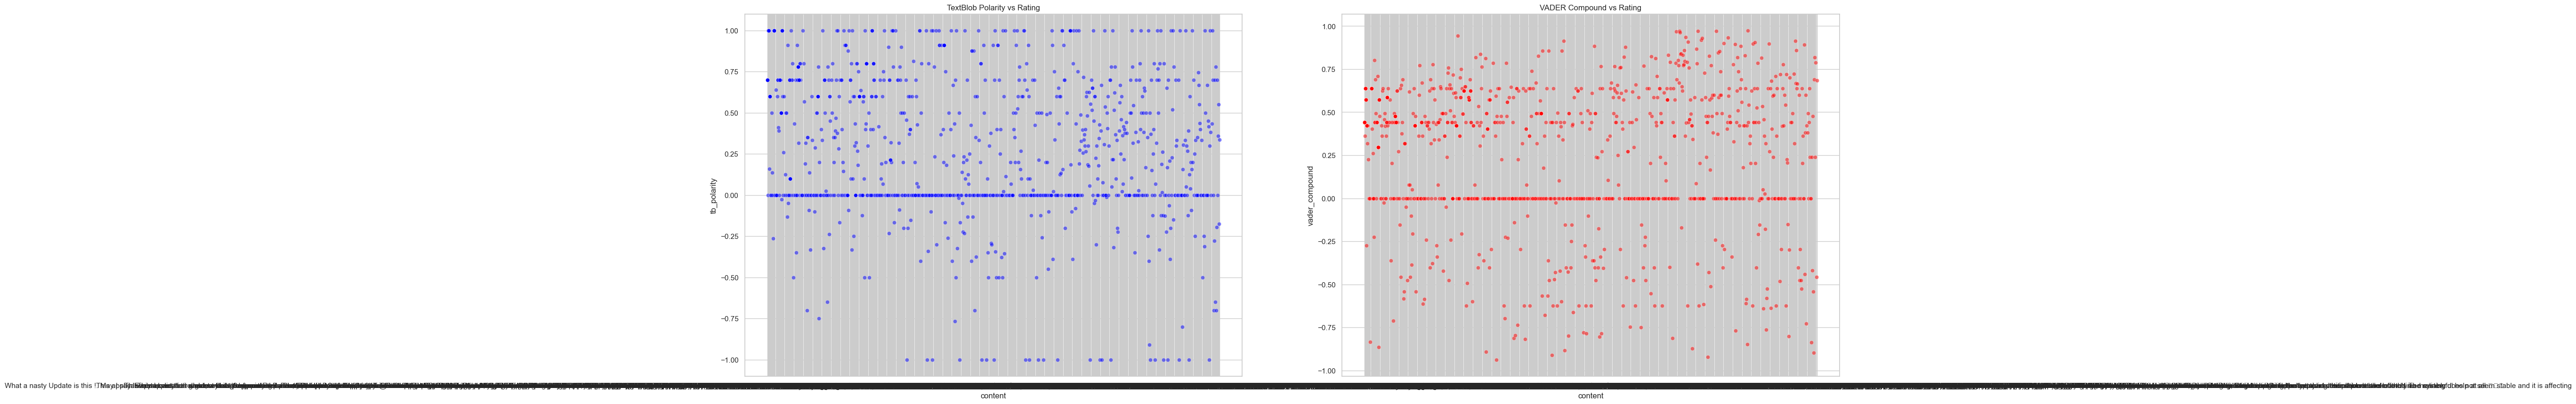

In [25]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(30, 10))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='content', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='content', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout()
plt.show()

In [26]:
print(df_clean.columns.tolist())

['content', 'bank', 'nouns', 'keywords', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'sentiment']


In [40]:
# Cell 11: Transformer Pipeline

import torch  # Add this import
from tqdm import tqdm
import pandas as pd
from tqdm import tqdm
try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16  # Adjust batch size as needed
    
    # FIXED: Changed 'review' to 'content'
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"):
        batch = df_clean['content'].iloc[i:i + batch_size].tolist()  # Changed 'review' to 'content'
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))
    
    # Display sample results
    print("\nSample results:")
    print(df_clean[['content', 'sentiment', 'transformer_sentiment_label', 'transformer_sentiment_score']].head())

except Exception as e:
    print(f"Transformer skipped: {e}")
    df_clean.to_csv("all_reviews.csv", index=False)


Running Transformer Sentiment: 100%|██████████| 75/75 [00:38<00:00,  1.94it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.63
NEGATIVE    0.37
Name: proportion, dtype: float64

Sample results:
     content sentiment transformer_sentiment_label  \
0       good  positive                    POSITIVE   
1  Thank you  positive                    POSITIVE   
2       good  positive                    POSITIVE   
3       best  positive                    POSITIVE   
4  excellent  positive                    POSITIVE   

   transformer_sentiment_score  
0                     0.999816  
1                     0.999835  
2                     0.999816  
3                     0.999794  
4                     0.999843  


In [37]:
import sys
!{sys.executable} -m pip install tqdm ipywidgets


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import sys
!{sys.executable} -m pip install --upgrade jupyter ipykernel ipywidgets


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


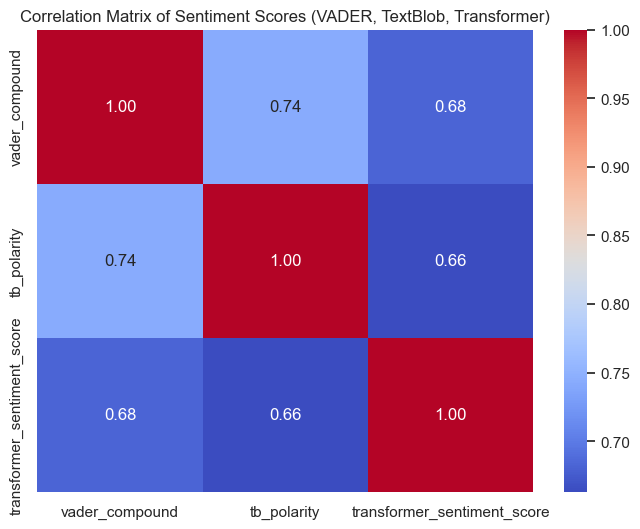

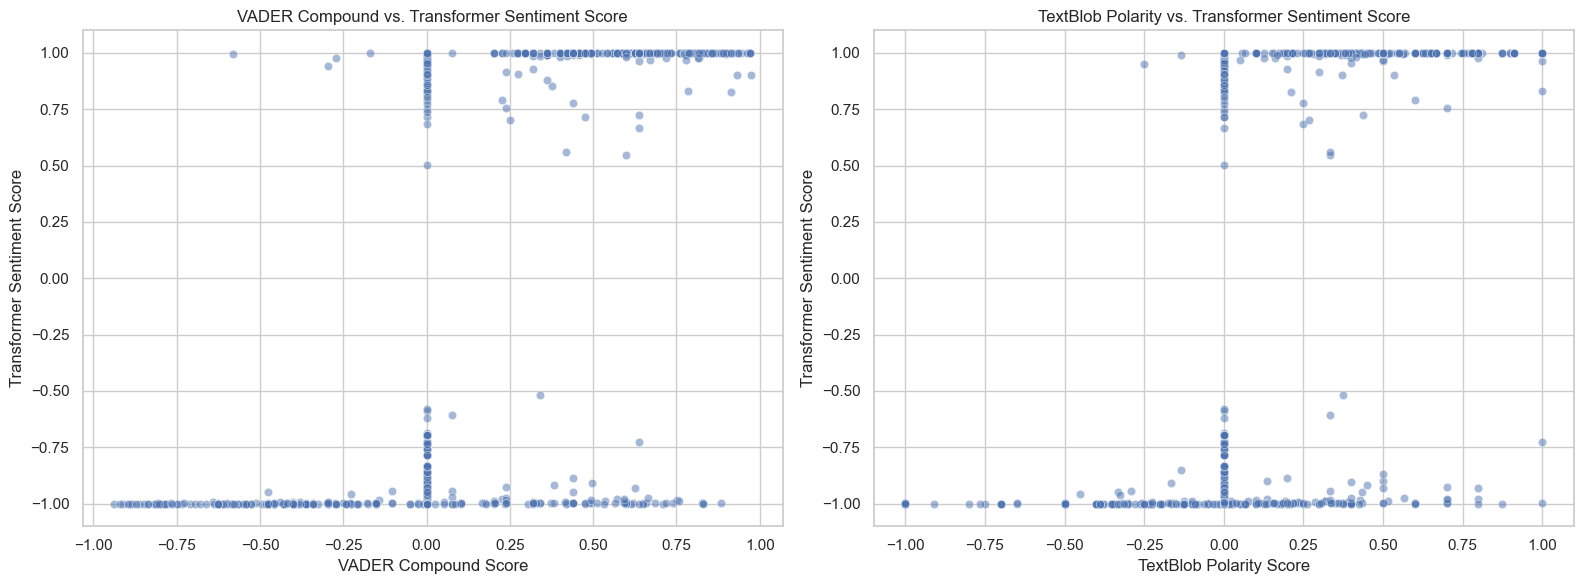

In [41]:
# Cell 11.1: Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

In [42]:
print(df_clean.columns.tolist())

['content', 'bank', 'nouns', 'keywords', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'sentiment', 'transformer_sentiment_label', 'transformer_sentiment_score']


In [43]:
print(df1.columns.tolist())
print(df2.columns.tolist())
print(df3.columns.tolist())

['content', 'bank']
['content', 'bank']
['content', 'bank']


In [44]:
print(df_clean.head())
print(df_clean["bank"].value_counts())

     content      bank        nouns     keywords  vader_compound  tb_polarity  \
0       good  CBE Bank           []       [good]          0.4404          0.7   
1  Thank you  CBE Bank      [thank]      [thank]          0.3612          0.0   
2       good  CBE Bank           []       [good]          0.4404          0.7   
3       best  CBE Bank           []       [best]          0.6369          1.0   
4  excellent  CBE Bank  [excellent]  [excellent]          0.5719          1.0   

   tb_subjectivity sentiment transformer_sentiment_label  \
0              0.6  positive                    POSITIVE   
1              0.0  positive                    POSITIVE   
2              0.6  positive                    POSITIVE   
3              0.3  positive                    POSITIVE   
4              1.0  positive                    POSITIVE   

   transformer_sentiment_score  
0                     0.999816  
1                     0.999835  
2                     0.999816  
3                   

In [49]:
df_clean.to_csv("all_reviews2.csv", index=False)

In [46]:
bank_map = {
    "CBE": 3,
    "BOA": 1,
    "DASHEN": 2
}

df_clean["bank_id"] = df_clean["bank"].map(bank_map)

In [47]:
df1 = pd.read_csv("../notebooks/dataprocessed/clear_output_cbe_reviews.csv")
df2 = pd.read_csv("../notebooks/dataprocessed/clear_output_BOA_reviews.csv")
df3 = pd.read_csv("../notebooks/dataprocessed/clear_output_DAHEN_reviews.csv")

df_clean = pd.concat([df1, df2, df3], ignore_index=True)

print(df_clean["bank"].value_counts())

bank
CBE Bank       400
BOA Bank       400
Dashen Bank    400
Name: count, dtype: int64


In [48]:
print(df_clean["bank"].unique())

['CBE Bank' 'BOA Bank' 'Dashen Bank']
